# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---


## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1)SAX преобразует временной ряд в последовательность символов через разбиение ряда на участки, вычисление средних значений на этих участках и их дискретизацию, а SFA сначала переводит ряд в частотную область с помощью преобразования Фурье, а затем символически кодирует коэффициенты спектра.SFA часто работает устойчивее если имеется высоскочастотный шум, так как SFA может сохранять наиболее информативные частотные компоненты, соответственно он меньше зависит от случайных локальных колебаний исходного сигнала.

2)BOSS разбивает временной ряд на окна, а потом с помощью SFA преобразует в слова и мы получаем гистограмм частот этих слов.В варианте BOSS-VS слова которые часто встречаются в определенном классе, но редко в других получают больший вес.Смысл в том, что
мы выделяем наиболее информативный шаблон сигнала, а наиболее распространенные избегаем.

3)Это короткий фрагмент временного ряда, с помощью которого можно отличить один класс объектов от другого.Классические методы ищут самые информативные последовательности, а ROCKET использует сверточные ядра и извлекает признаки с помощью них.После чего происходит обучение линейного классификатора.

4)Потому что catch22 извлекает набор характеристик которые хорошо интерпретируемы.Такой способ меньше ресурсов использует, а полученные признаки проще объяснить.Нейросеть эффективнее на больших выборках,но catch22 подходит лучше для небольшого набора данных

5)Они эффективны потому что сверточные фильтры находят повторяющиеся шаблоны.Inception Time использует несколько параллельных сетей с ядрами разного размера.Это помогает разпознать короткие событие и длинные структуры у сигнала.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

In [1]:
%pip install -U sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 7.4 MB/s eta 0:00:00


X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


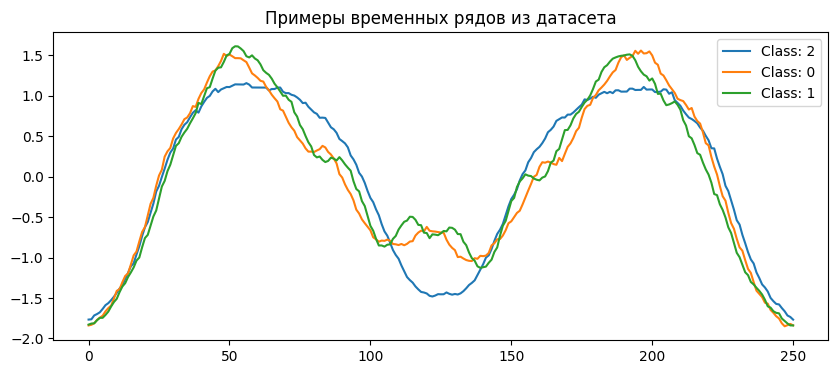

In [2]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [3]:
from sktime.classification.kernel_based import RocketClassifier
import time

# Ваш код здесь...
rocket_clf = RocketClassifier(num_kernels=1000,random_state=42,n_jobs=-1)
start_time = time.perf_counter()
rocket_clf.fit(X_train, y_train)
training_time_rocket = time.perf_counter() - start_time
y_pred_rocket = rocket_clf.predict(X_test)
accuracy_rocket = accuracy_score(y_test, y_pred_rocket)
print("Модель: ROCKET")
print(f"Accuracy: {accuracy_rocket:.4f}")
print(f"Время обучения: {training_time_rocket:.4f} секунд")

print("\nИстинные классы:")
print(y_test)

print("\nПредсказанные классы:")
print(y_pred_rocket)

print("\nОтчёт о классификации:")
print(
    classification_report(
        y_test,
        y_pred_rocket,
        zero_division=0
    )
)

Модель: ROCKET
Accuracy: 0.9219
Время обучения: 13.1679 секунд

Истинные классы:
['0' '2' '1' '0' '0' '2' '0' '2' '0' '0' '1' '2' '1' '0' '0' '2' '2' '0'
 '2' '0' '0' '0' '1' '2' '1' '1' '1' '0' '1' '2' '1' '1' '1' '0' '0' '1'
 '2' '0' '2' '0' '1' '2' '2' '1' '1' '0' '0' '0' '0' '0' '0' '2' '1' '2'
 '1' '2' '0' '0' '0' '2' '2' '0' '0' '2']

Предсказанные классы:
['0' '2' '1' '0' '0' '2' '0' '2' '0' '0' '1' '2' '1' '1' '0' '2' '2' '0'
 '2' '0' '0' '0' '1' '2' '1' '1' '1' '0' '1' '2' '1' '1' '1' '0' '0' '1'
 '2' '0' '2' '0' '1' '0' '2' '1' '1' '0' '0' '0' '0' '0' '0' '2' '1' '2'
 '1' '0' '0' '0' '0' '1' '2' '2' '0' '2']

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        28
           1       0.89      1.00      0.94        17
           2       0.94      0.84      0.89        19

    accuracy                           0.92        64
   macro avg       0.92      0.92      0.92        64
weighted avg       0.92 

### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

Модель: ContractableBOSS
Accuracy: 0.9531
Время обучения: 27.6199 секунд

Истинные классы:
['0' '2' '1' '0' '0' '2' '0' '2' '0' '0' '1' '2' '1' '0' '0' '2' '2' '0'
 '2' '0' '0' '0' '1' '2' '1' '1' '1' '0' '1' '2' '1' '1' '1' '0' '0' '1'
 '2' '0' '2' '0' '1' '2' '2' '1' '1' '0' '0' '0' '0' '0' '0' '2' '1' '2'
 '1' '2' '0' '0' '0' '2' '2' '0' '0' '2']

Предсказанные классы:
['0' '2' '1' '0' '0' '2' '0' '2' '0' '0' '1' '2' '1' '0' '0' '2' '2' '0'
 '2' '0' '0' '0' '1' '2' '1' '1' '1' '0' '1' '2' '1' '1' '1' '0' '0' '1'
 '2' '0' '2' '1' '1' '1' '2' '0' '1' '0' '0' '0' '0' '0' '0' '2' '1' '2'
 '1' '2' '0' '0' '0' '2' '2' '0' '0' '2']

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.89      0.94      0.91        17
           2       1.00      0.95      0.97        19

    accuracy                           0.95        64
   macro avg       0.95      0.95      0.95        64
weighted avg  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/parallel.py:128: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


,Модель,Accuracy,"Время обучения, сек."
0,ROCKET,0.9219,13.1679
1,ContractableBOSS,0.9531,27.6199


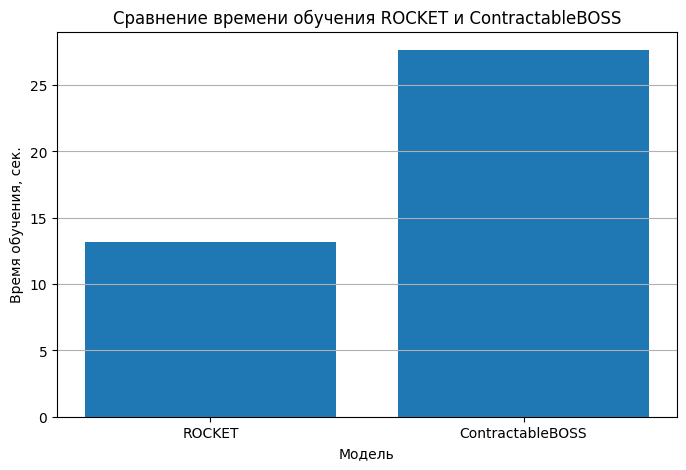

In [4]:
import pandas as pd
from sktime.classification.dictionary_based import ContractableBOSS

# Ваш код здесь...
cboss_clf = ContractableBOSS(
    n_parameter_samples=10,
    max_ensemble_size=3,
    feature_selection="chi2",
    random_state=42,
    n_jobs=-1
)


start_time = time.perf_counter()
cboss_clf.fit(X_train, y_train)
training_time_cboss = time.perf_counter() - start_time
y_pred_cboss = cboss_clf.predict(X_test)
accuracy_cboss = accuracy_score(y_test, y_pred_cboss)
print("Модель: ContractableBOSS")
print(f"Accuracy: {accuracy_cboss:.4f}")
print(f"Время обучения: {training_time_cboss:.4f} секунд")
print("\nИстинные классы:")
print(y_test)
print("\nПредсказанные классы:")
print(y_pred_cboss)
print("\nОтчёт о классификации:")
print(
    classification_report(
        y_test,
        y_pred_cboss,
        zero_division=0
    )
)
comparison_rocket_cboss = pd.DataFrame({
    "Модель": ["ROCKET", "ContractableBOSS"],
    "Accuracy": [accuracy_rocket, accuracy_cboss],
    "Время обучения, сек.": [
        training_time_rocket,
        training_time_cboss
    ]
})

print("\nСравнение ROCKET и ContractableBOSS:")
display(comparison_rocket_cboss.round(4))
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_rocket_cboss["Модель"],
    comparison_rocket_cboss["Время обучения, сек."]
)

plt.title("Сравнение времени обучения ROCKET и ContractableBOSS")
plt.xlabel("Модель")
plt.ylabel("Время обучения, сек.")
plt.grid(axis="y")
plt.show()

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch).
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [6]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.flatten = nn.Flatten()

        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
# ваш код здесь
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Используемое устройство:", device)
print("Исходный размер X_train:", X_train.shape)
print("Исходный размер X_test:", X_test.shape)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Классы:", label_encoder.classes_)
print("Закодированные метки train:", y_train_encoded[:10])
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Размер батча train:", next(iter(train_loader))[0].shape)

Используемое устройство: cpu
Исходный размер X_train: (147, 1, 251)
Исходный размер X_test: (64, 1, 251)
Классы: ['0' '1' '2']
Закодированные метки train: [2 0 1 2 1 0 2 1 0 1]
Размер батча train: torch.Size([8, 1, 251])


In [8]:
num_classes = len(label_encoder.classes_)
cnn_model = Simple1DCNN(num_classes=num_classes).to(device)
print(cnn_model)

Simple1DCNN(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3904, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [9]:
from tqdm.auto import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)
num_epochs = 30
train_losses = []
train_accuracies = []
start_time = time.perf_counter()
for epoch in tqdm(
    range(num_epochs),
    desc="Обучение 1D-CNN",
    unit="эпоха"
):
    cnn_model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_objects = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
        predicted_classes = torch.argmax(outputs, dim=1)
        correct_predictions += (
            predicted_classes == batch_y
        ).sum().item()

        total_objects += batch_y.size(0)
    epoch_loss = running_loss / total_objects
    epoch_accuracy = correct_predictions / total_objects

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

training_time_cnn = time.perf_counter() - start_time

print("\nОбучение завершено.")
print(f"Время обучения 1D-CNN: {training_time_cnn:.4f} секунд")
print(f"Последнее значение loss: {train_losses[-1]:.4f}")
print(f"Accuracy на обучающей выборке: {train_accuracies[-1]:.4f}")

Обучение 1D-CNN:   0%|          | 0/30 [00:00<?, ?эпоха/s]


Обучение завершено.
Время обучения 1D-CNN: 6.6595 секунд
Последнее значение loss: 0.1143
Accuracy на обучающей выборке: 0.9456


In [11]:
cnn_model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = cnn_model(batch_X)

        predicted_classes = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predicted_classes.cpu().numpy()
        )

        all_true_labels.extend(
            batch_y.numpy()
        )

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

accuracy_cnn = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Модель: 1D-CNN")
print(f"Accuracy: {accuracy_cnn:.4f}")
print(f"Время обучения: {training_time_cnn:.4f} секунд")

print("\nИстинные классы:")
print(all_true_labels)

print("\nПредсказанные классы:")
print(all_predictions)

print("\nОтчёт о классификации:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=[str(cls) for cls in label_encoder.classes_],
        zero_division=0
    )
)

Модель: 1D-CNN
Accuracy: 0.7812
Время обучения: 6.6595 секунд

Истинные классы:
[0 2 1 0 0 2 0 2 0 0 1 2 1 0 0 2 2 0 2 0 0 0 1 2 1 1 1 0 1 2 1 1 1 0 0 1 2
 0 2 0 1 2 2 1 1 0 0 0 0 0 0 2 1 2 1 2 0 0 0 2 2 0 0 2]

Предсказанные классы:
[0 2 1 0 1 2 0 2 0 0 1 2 1 1 0 2 2 0 2 0 1 0 1 2 1 1 1 0 1 1 1 1 1 0 0 0 2
 0 1 1 1 1 2 1 0 1 0 0 0 0 0 2 1 0 1 1 0 0 0 1 2 1 0 2]

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.58      0.88      0.70        17
           2       1.00      0.68      0.81        19

    accuracy                           0.78        64
   macro avg       0.82      0.78      0.78        64
weighted avg       0.84      0.78      0.79        64



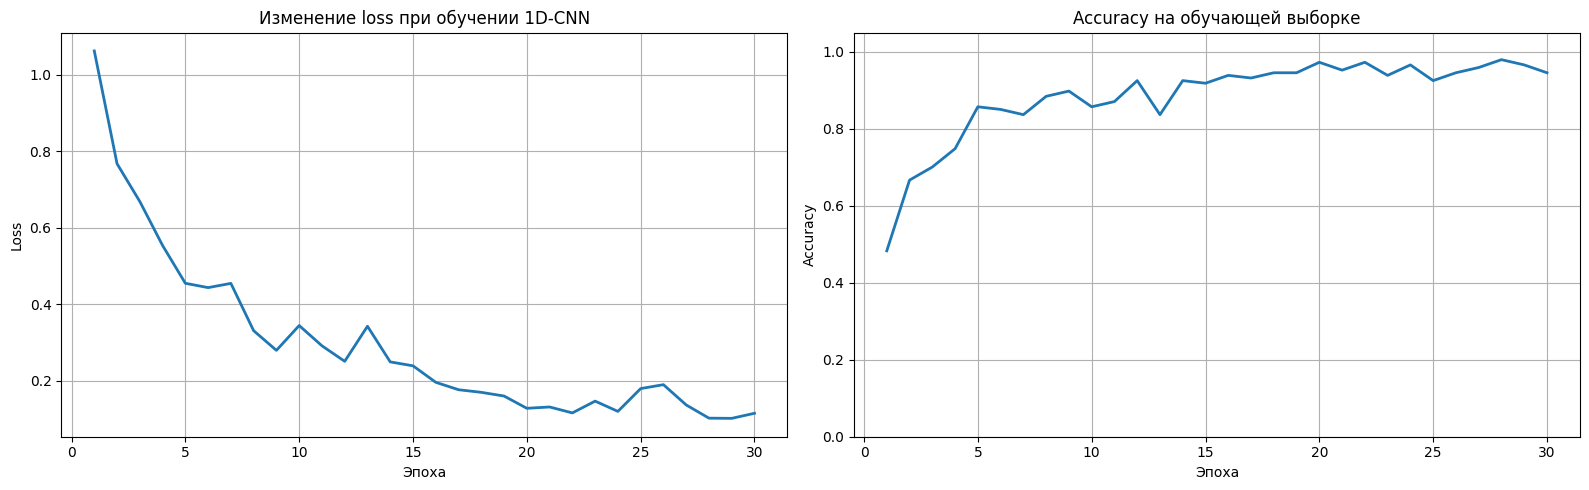

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    range(1, num_epochs + 1),
    train_losses,
    linewidth=2
)

axes[0].set_title("Изменение loss при обучении 1D-CNN")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[1].plot(
    range(1, num_epochs + 1),
    train_accuracies,
    linewidth=2
)

axes[1].set_title("Accuracy на обучающей выборке")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True)

plt.tight_layout()
plt.show()

Сравнение методов классификации временных рядов:


,Модель,Accuracy,"Время обучения, сек."
0,ROCKET,0.9219,13.1679
1,ContractableBOSS,0.9531,27.6199
2,1D-CNN,0.7812,6.6595


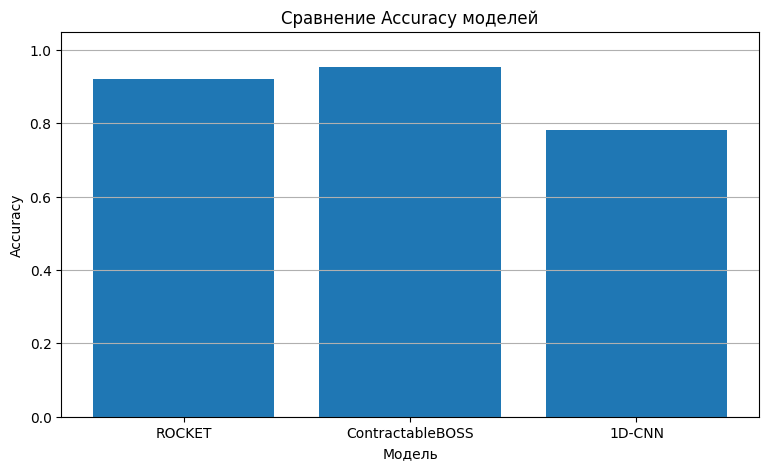

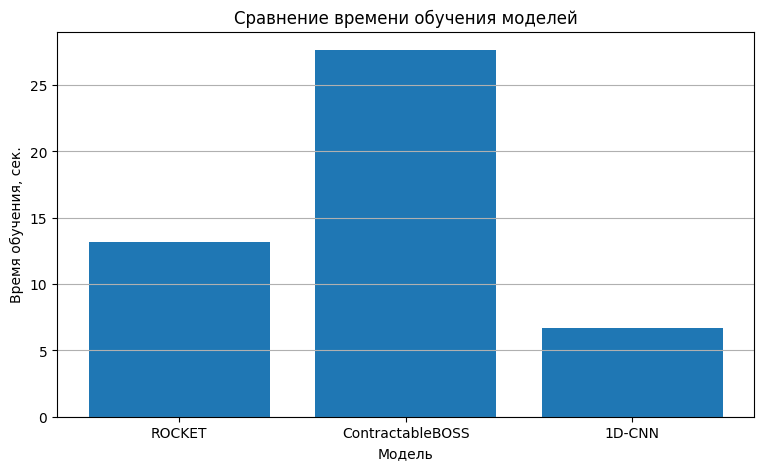

Наибольшую точность показала модель ContractableBOSS: Accuracy = 0.9531


In [13]:
comparison_models = pd.DataFrame({
    "Модель": [
        "ROCKET",
        "ContractableBOSS",
        "1D-CNN"
    ],
    "Accuracy": [
        accuracy_rocket,
        accuracy_cboss,
        accuracy_cnn
    ],
    "Время обучения, сек.": [
        training_time_rocket,
        training_time_cboss,
        training_time_cnn
    ]
})

print("Сравнение методов классификации временных рядов:")
display(comparison_models.round(4))
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_models["Модель"],
    comparison_models["Accuracy"]
)

plt.title("Сравнение Accuracy моделей")
plt.xlabel("Модель")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.show()
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_models["Модель"],
    comparison_models["Время обучения, сек."]
)

plt.title("Сравнение времени обучения моделей")
plt.xlabel("Модель")
plt.ylabel("Время обучения, сек.")
plt.grid(axis="y")
plt.show()
best_model = comparison_models.loc[
    comparison_models["Accuracy"].idxmax()
]

print(
    f"Наибольшую точность показала модель "
    f"{best_model['Модель']}: "
    f"Accuracy = {best_model['Accuracy']:.4f}"
)

метод ContractableBOSS показал самый лучший результат по качеству,а 1D-CNN обучилась быстрее всех